# Notebook 04 — Cluster Routing (Improved)

Attaches cluster assignments to the daily splits from notebook 03 and applies one
improvement over the prior team: **splitting C1 into C1a (seasonal) and C1b (non-seasonal)**.

## Why split C1?
C1 is labeled "Seasonal-Intermittent" and routed to Prophet. But 156 of 473 C1 products
have `stl_seasonality_strength < 0.5` on the daily series (period=7, day-of-week seasonality).
These products have no meaningful weekly pattern — applying Prophet to them drags down C1's MAPE
and makes Prophet look worse than it is.

**Why use daily STL, not weekly STL?**  
C1's defining seasonality is day-of-week (e.g. gift products selling only on weekdays).
This is captured by STL with period=7 on daily data. Weekly STL (period=52) is unreliable
on only 73 training weeks (1.4 annual cycles) and would measure annual seasonality — a
different and weaker signal for this cluster.

## Cluster key (v2)
| cluster | label | model |
|---------|-------|-------|
| 0 | C0 Erratic | LGBM / N-BEATS |
| 1 | C1a Seasonal (daily STL ≥ 0.5) | Prophet |
| 5 | C1b Non-Seasonal (daily STL < 0.5) | LGBM / N-BEATS |
| 2 | C2 Dense HiVol | Prophet + global LGBM |
| 3 | C3 Sparse Long-Tail | DeepAR |
| 4 | C4 Ultra-Sparse | SWLY rule |

Products not in the cluster table (below activity filter) are left with `cluster = NaN` —
do not assign them to C3. Excluding them from modeling is the correct call.

Inputs:
- `data/daily_train.parquet` / `val` / `test` (from notebook 03)
- `data/clustering/clusters_3models.parquet`
- `data/clustering/feature_table_extended.parquet`

Outputs:
- `data/clustering/clusters_improved.parquet` — per-product cluster assignments (v2)
- `data/daily_train_clustered.parquet` / `val` / `test`
- `data/daily_train_winsorized_clustered.parquet` / `val` / `test`

## Prior session note — Weekly STL recomputation attempt

An earlier session (notebook 02, now deleted) attempted to recompute STL and ACF features
at weekly granularity before running the C1 split, producing .
That notebook ran on the **corrupt weekly data** (all  due to a Timestamp
merge key mismatch in notebook 01 — since fixed). As a result, all weekly features came back
all-NaN/zero and the weekly STL values were unusable.

Two additional findings from that session, both confirmed and acted on here:

1. **Weekly STL (period=52) is unreliable on ~73 training weeks** (only 1.4 annual cycles —
   insufficient to fit annual seasonality). Using daily STL (period=7, day-of-week seasonality)
   from  is the correct basis for the C1 split — it is the
   exact feature that drove C1 classification in the first place.

2. **Redundant feature pairs (r > 0.90)** in the 50-feature set were identified (7 pairs with
   r ≥ 0.999). Re-running K-Means after dropping these was tested in notebook 05 — ARI=0.54
   and silhouette dropped, so original assignments were kept.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

DATA  = Path('../data')
CLUST = DATA / 'clustering'

CLUSTER_LABELS = {
    0: 'C0 Erratic',
    1: 'C1a Seasonal',
    2: 'C2 Dense HiVol',
    3: 'C3 Sparse Long-Tail',
    4: 'C4 Ultra-Sparse',
    5: 'C1b Non-Seasonal',
}

## 1. Load cluster assignments and feature table

In [2]:
clusters_orig = pd.read_parquet(CLUST / 'clusters_3models.parquet')[['cluster_kmeans']]
clusters_orig.columns = ['cluster']
clusters_orig.index.name = 'product_family_name'

ft = pd.read_parquet(CLUST / 'feature_table_extended.parquet')[['stl_seasonality_strength']]

print('Original cluster distribution:')
for k, v in clusters_orig['cluster'].value_counts().sort_index().items():
    print(f'  {CLUSTER_LABELS.get(k, k):25s} (cluster {k}): {v}')

print(f'\nC1 daily STL distribution:')
c1_stl = ft.loc[clusters_orig[clusters_orig['cluster'] == 1].index, 'stl_seasonality_strength']
print(c1_stl.describe().round(3))

Original cluster distribution:
  C0 Erratic                (cluster 0): 515
  C1a Seasonal              (cluster 1): 473
  C2 Dense HiVol            (cluster 2): 10
  C3 Sparse Long-Tail       (cluster 3): 1017
  C4 Ultra-Sparse           (cluster 4): 8

C1 daily STL distribution:
count    473.000
mean       0.705
std        0.359
min       -0.978
25%        0.401
50%        0.961
75%        1.000
max        1.000
Name: stl_seasonality_strength, dtype: float64


## 2. C1 split analysis

Visualize daily STL distribution for C1 and confirm the 0.5 threshold is a natural break.

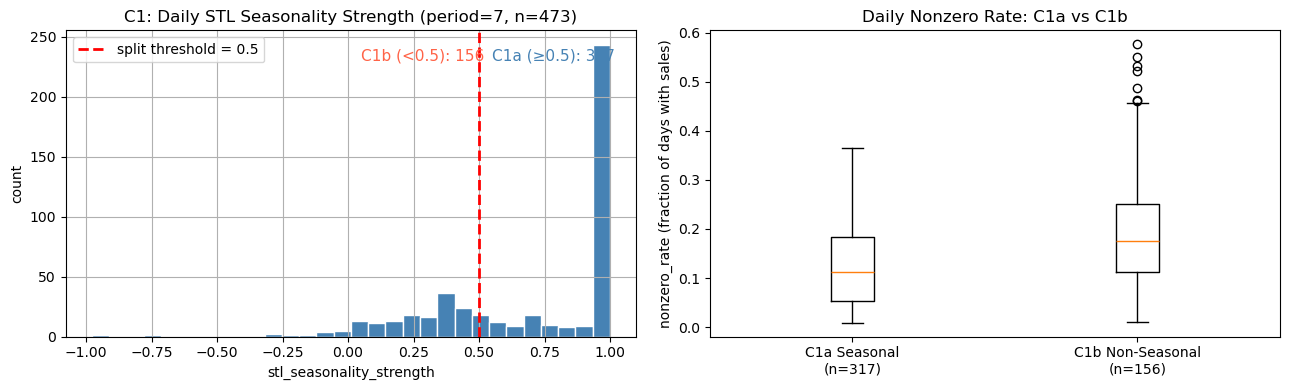

C1a (STL ≥ 0.5): 317 products → Prophet
C1b (STL < 0.5): 156 products → LGBM / N-BEATS

Mean nonzero_rate — C1a: 0.126,  C1b: 0.193
(Higher nonzero_rate in C1b → more like C0 Erratic, confirms LGBM routing)


In [3]:
c1_products = clusters_orig[clusters_orig['cluster'] == 1].index
c1_stl = ft.loc[c1_products, 'stl_seasonality_strength'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram with proposed split
c1_stl.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='split threshold = 0.5')
axes[0].set_title(f'C1: Daily STL Seasonality Strength (period=7, n={len(c1_stl)})')
axes[0].set_xlabel('stl_seasonality_strength')
axes[0].set_ylabel('count')
axes[0].legend()

# Annotate counts
n_c1a = (c1_stl >= 0.5).sum()
n_c1b = (c1_stl <  0.5).sum()
axes[0].text(0.55, axes[0].get_ylim()[1] * 0.9, f'C1a (≥0.5): {n_c1a}', color='steelblue', fontsize=11)
axes[0].text(0.05, axes[0].get_ylim()[1] * 0.9, f'C1b (<0.5): {n_c1b}', color='tomato', fontsize=11)

# Key feature comparison: nonzero_rate
ft_full = pd.read_parquet(CLUST / 'feature_table_extended.parquet')
c1_all  = ft_full.loc[c1_products]
c1a_mask = c1_all['stl_seasonality_strength'].fillna(1.0) >= 0.5

axes[1].boxplot(
    [c1_all.loc[c1a_mask,  'nonzero_rate'].dropna(),
     c1_all.loc[~c1a_mask, 'nonzero_rate'].dropna()],
    labels=[f'C1a Seasonal\n(n={c1a_mask.sum()})', f'C1b Non-Seasonal\n(n={(~c1a_mask).sum()})']
)
axes[1].set_title('Daily Nonzero Rate: C1a vs C1b')
axes[1].set_ylabel('nonzero_rate (fraction of days with sales)')

plt.tight_layout()
plt.savefig(CLUST / 'c1_split_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'C1a (STL ≥ 0.5): {n_c1a} products → Prophet')
print(f'C1b (STL < 0.5): {n_c1b} products → LGBM / N-BEATS')
print(f'\nMean nonzero_rate — C1a: {c1_all.loc[c1a_mask, "nonzero_rate"].mean():.3f},  '
      f'C1b: {c1_all.loc[~c1a_mask, "nonzero_rate"].mean():.3f}')
print('(Higher nonzero_rate in C1b → more like C0 Erratic, confirms LGBM routing)')

## 3. Build improved cluster assignments (v2)

In [4]:
clusters_v2 = clusters_orig[['cluster']].copy()

# C1b: daily STL < 0.5 → cluster 5
c1b_products = ft.loc[
    clusters_orig[clusters_orig['cluster'] == 1].index
].query('stl_seasonality_strength < 0.5').index

clusters_v2.loc[c1b_products, 'cluster'] = 5

print('Improved cluster distribution (v2):')
for k, v in clusters_v2['cluster'].value_counts().sort_index().items():
    print(f'  cluster {k}  {CLUSTER_LABELS.get(k, k):25s}: {v}')

clusters_v2.reset_index().to_parquet(CLUST / 'clusters_improved.parquet', index=False)
print('\nSaved clusters_improved.parquet')

Improved cluster distribution (v2):
  cluster 0  C0 Erratic               : 515
  cluster 1  C1a Seasonal             : 317
  cluster 2  C2 Dense HiVol           : 10
  cluster 3  C3 Sparse Long-Tail      : 1017
  cluster 4  C4 Ultra-Sparse          : 8
  cluster 5  C1b Non-Seasonal         : 156

Saved clusters_improved.parquet


## 4. Attach clusters to daily splits

Products outside the cluster table (not in `clusters_3models.parquet`) are below the
activity filter and correctly excluded. They get `cluster = NaN`, not C3.
The prior team incorrectly assigned them to C3, inflating C3 from its true 1017 to 1568.

In [5]:
cluster_col = clusters_v2.reset_index()[['product_family_name', 'cluster']]

def attach_and_save(split_name, suffix=''):
    df = pd.read_parquet(DATA / f'daily_{split_name}{suffix}.parquet')
    merged = df.merge(cluster_col, on='product_family_name', how='left')
    
    n_unmatched = merged['cluster'].isna().any()
    if n_unmatched:
        unmatched_prods = merged[merged['cluster'].isna()]['product_family_name'].nunique()
        print(f'[{split_name}{suffix}] {unmatched_prods} products have no cluster (below activity filter) → cluster=NaN')
    
    out_name = f'daily_{split_name}_clustered{suffix}.parquet'
    merged.to_parquet(DATA / out_name, index=False)
    
    # Cluster distribution (products only, not rows)
    dist = merged.drop_duplicates('product_family_name')['cluster'].value_counts().sort_index()
    print(f'[{split_name}{suffix}] saved {out_name} | {len(merged):,} rows | cluster dist: {dist.to_dict()}')
    return merged

train_cl = attach_and_save('train')
val_cl   = attach_and_save('val')
test_cl  = attach_and_save('test')

[train] 13 products have no cluster (below activity filter) → cluster=NaN


[train] saved daily_train_clustered.parquet | 771,644 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[val] 13 products have no cluster (below activity filter) → cluster=NaN
[val] saved daily_val_clustered.parquet | 138,448 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[test] 13 products have no cluster (below activity filter) → cluster=NaN


[test] saved daily_test_clustered.parquet | 319,652 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}


In [6]:
# Also attach to winsorized splits (used for model training)
train_wc = attach_and_save('train', suffix='_winsorized')
val_wc   = attach_and_save('val',   suffix='_winsorized')
test_wc  = attach_and_save('test',  suffix='_winsorized')

[train_winsorized] 13 products have no cluster (below activity filter) → cluster=NaN


[train_winsorized] saved daily_train_clustered_winsorized.parquet | 771,644 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[val_winsorized] 13 products have no cluster (below activity filter) → cluster=NaN
[val_winsorized] saved daily_val_clustered_winsorized.parquet | 138,448 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[test_winsorized] 13 products have no cluster (below activity filter) → cluster=NaN


[test_winsorized] saved daily_test_clustered_winsorized.parquet | 319,652 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}


## 5. Summary table

In [7]:
# Profile each cluster on train data
prods = train_cl.drop_duplicates('product_family_name')

summary = (
    train_cl[train_cl['cluster'].notna()]
    .groupby('cluster')
    .agg(
        n_products=('product_family_name', 'nunique'),
        mean_daily_sales=('total_sales', 'mean'),
        zero_rate=('total_sales', lambda x: (x == 0).mean()),
        max_daily_sales=('total_sales', 'max'),
    )
    .round(3)
)
summary['label'] = summary.index.map(CLUSTER_LABELS)
summary = summary[['label', 'n_products', 'mean_daily_sales', 'zero_rate', 'max_daily_sales']]

print('\nCluster summary (daily train, unwinsorized):')
print(summary.to_string())

print('\nModel routing:')
routing = {
    0: 'LGBM + N-BEATS',
    1: 'Prophet',
    2: 'Prophet + global LGBM',
    3: 'DeepAR',
    4: 'SWLY rule',
    5: 'LGBM + N-BEATS',
}
for k, v in sorted(routing.items()):
    label = CLUSTER_LABELS.get(k, str(k))
    n = summary.loc[k, 'n_products'] if k in summary.index else 0
    print(f'  cluster {k}  {label:25s} (n={n:4})  →  {v}')


Cluster summary (daily train, unwinsorized):
                       label  n_products  mean_daily_sales  zero_rate  max_daily_sales
cluster                                                                               
0.0               C0 Erratic         515            28.555      0.423         19107.38
1.0             C1a Seasonal         317             6.658      0.855          4282.32
2.0           C2 Dense HiVol          10           594.300      0.047         23087.51
3.0      C3 Sparse Long-Tail        1017             3.311      0.861         77183.60
4.0          C4 Ultra-Sparse           8             3.894      0.998          6074.70
5.0         C1b Non-Seasonal         156            10.496      0.776          6225.22

Model routing:
  cluster 0  C0 Erratic                (n= 515)  →  LGBM + N-BEATS
  cluster 1  C1a Seasonal              (n= 317)  →  Prophet
  cluster 2  C2 Dense HiVol            (n=  10)  →  Prophet + global LGBM
  cluster 3  C3 Sparse Long-Tail       (n

## 6. Sanity checks

In [8]:
assert train_cl['date'].max() < val_cl['date'].min(), 'Train/val leakage'
assert val_cl['date'].max()   < test_cl['date'].min(), 'Val/test leakage'
print('No temporal leakage.')

# No product should appear in C1 AND C5 (split should be exclusive)
c1_prods = set(train_cl[train_cl['cluster'] == 1]['product_family_name'].unique())
c5_prods = set(train_cl[train_cl['cluster'] == 5]['product_family_name'].unique())
assert len(c1_prods & c5_prods) == 0, 'C1/C5 overlap'
print(f'C1a + C1b are disjoint. C1a: {len(c1_prods)}, C1b: {len(c5_prods)}, total: {len(c1_prods) + len(c5_prods)}')

# C1a + C1b should equal original C1
orig_c1 = (clusters_orig['cluster'] == 1).sum()
assert len(c1_prods) + len(c5_prods) == orig_c1, f'C1 count mismatch: {len(c1_prods)+len(c5_prods)} vs {orig_c1}'
print(f'C1a ({len(c1_prods)}) + C1b ({len(c5_prods)}) = {orig_c1} = original C1 ✓')

# Confirm no unmatched products got cluster assignment
# (they should all be NaN)
matched = train_cl[train_cl['cluster'].notna()]['product_family_name'].nunique()
expected = len(clusters_v2)
print(f'Matched products: {matched} (expected {expected})')

print('\nAll checks passed.')

No temporal leakage.


C1a + C1b are disjoint. C1a: 317, C1b: 156, total: 473
C1a (317) + C1b (156) = 473 = original C1 ✓
Matched products: 2023 (expected 2023)

All checks passed.
